In [1]:
%pip install -e "../weac"

Obtaining file:///Users/rheinschmidt/Documents/20-29%20-%20Forschung/22%20-%20weakInterface/weac
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for weac (pyproject.toml) ... done
  Created wheel for weac: filename=weac-3.0.1-0.editable-py3-none-any.whl size=9710 sha256=85298d763270730d721d7d14a54c0f4e7756df7b8a21ec416e7b402428918312
  Stored in directory: /private/var/folders/v5/vn5xms9d4994mfsg86gg1zt80000gn/T/pip-ephem-wheel-cache-596z403o/wheels/f7/99/61/9690b5a4938babf9ead1feea64dff771fe96799fd66a2b3c38
Successfully built weac
  Attempting uninstall: weac
    Found existing installation: weac 3.0.1
    Uninstalling weac-3.0.1:
      Successfully uninstalled weac-3.0.1

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to rest

In [1]:
import numpy as np 
import pandas as pd

import sys
import matplotlib.pyplot as plt




In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
def gerling(rho, C0=6.5, C1=4.4):
    """
    Compute Young's modulus from density according to Gerling et al. 2017.

    Arguments
    ---------
    rho : float or ndarray
        Density (kg/m^3).
    C0 : float, optional
        Multiplicative constant of Young modulus parametrization
        according to Gerling et al. (2017). Default is 6.0.
    C1 : float, optional
        Exponent of Young modulus parameterization according to
        Gerling et al. (2017). Default is 4.6.

    Returns
    -------
    E : float or ndarray
        Young's modulus (MPa).
    """
    return C0*1000.*(rho/917.)**C1


Valles Tests

In [4]:
layers = [[300,110]]

phi=-38
theta = 20
test0 = oop.Layered(layers=layers, system = 'skier', phi = phi , theta = theta)
test0.b = 300
test0.set_foundation_properties(E=0.25,t=10,update=True)

segments = test0.calc_segments(L=10000, a  = 200,m = 80, phi = phi, theta = theta)['crack']
C0 = test0.assemble_and_solve(phi = phi, 
                            theta = theta,
                            **segments)
xwl, z, xsl = test0.rasterize_solution(C0,phi=phi, theta = theta,**segments)

plt.plot(xwl,test0.u(z))


NameError: name 'oop' is not defined

[[3.00000000e+02 1.10000000e+02 4.75866104e+01 1.90346442e+01
  2.50000000e-01]]
0.49050000000000005
{'li': array([300, 100,   0]), 'mi': array([0, 0]), 'ki': array([ True, False, False]), 'wi': array([False,  True, False])}


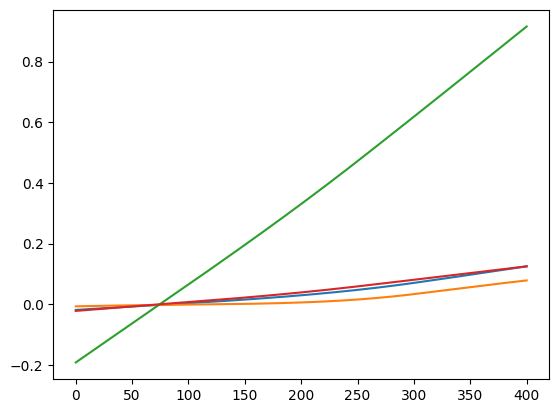

[2.72076615 1.54908063 0.0591726  1.11251292] [0.41637809 0.2481382  0.01454812 0.15369177]


In [ ]:
layers = [[300,110]]

phi=-26
V=90
case0 = oop.Layered(layers=layers,system='-pst',phi = phi ,theta=0)
case0.b = 300
case0.set_foundation_properties(E=0.25, t = 10., update = True)

segments =case0.calc_segments(L = 400, a = 150, m = 0)['crack']
print(case0.slab)
C0 = case0.assemble_and_solve(phi = phi, 
                            theta = 0,
                            frame = False,
                            verticalLoad=True,
                            V=[V,55],
                            **segments)

xwl0, z0, xsl = case0.rasterize_solution(C0,phi=phi, theta = 0,**segments)
g0 = case0.gdif(C0, phi=phi, theta = 0,unit ='J/m^2', **segments)



case1 = oop.Layered(layers=layers,system='modeIII-pst-loaded',phi = phi,theta=0)
case1.b = 300
case1.set_modeIII_surface_load()
case1.set_foundation_properties(E=1.5, t = 10., update = True)
print(case1.p)

segments =case1.calc_segments(L = 400, a = 100,b=100, m = 0)['crack']
print(segments)
C1 = case1.assemble_and_solve(phi = phi, 
                            theta = 0,
                            frame = False,
                            verticalLoad=True,
                            V=[V,55],
                            **segments)

xwl1, z1, xsl = case1.rasterize_solution(C1,phi=phi, theta = 0,**segments)
g1 = case1.gdif(C1, phi=phi, theta = 0,unit ='J/m^2', **segments)


plt.plot(xwl1,case1.v(z1))
plt.plot(xwl1,case1.w(z1))

plt.plot(xwl0,case0.v(z0))
plt.plot(xwl0,case0.w(z0))
plt.show()
print(g0,g1)


In [2]:
def get_additional_weight_load(H=0,l=0, n=0, phi = 0, theta = 0, frame = True, case = 0):
    """
    Calculate skier point load.

    Arguments
    ---------
    m : float
        Skier weight (kg).
    phi : float
        Inclination (degrees). Counterclockwise positive.

    Returns
    -------
    Fn : float
        Skier load (N) in normal direction.
    Ft : float
        Skier load (N) in tangential direction.
    """

    phi = np.deg2rad(phi)                   # Convert inclination to rad
    theta = np.deg2rad(theta)               # Convert rotation to rad
    if l==np.nan or n == np.nan or n ==0:
        frame = False
        n = 0
        l = 0
    
    n_rod = n/2.        # Number of rows of rods
    m_rod = 1.2         # kg
    m_frame = 0.7       # kg
    kg2t = 1e-3         # converion factor from kg->t
    b_block = 290   # out-of-plane width of snow block
    b_frame = 300.      # mm
    a_frame = 120.      # mm
    l_rod = 600.        # mm
    t_rod = 25.         # mm
    h_block = H   # mm
    g = 9810          # mm/s^2

    
    y_frame = -b_block/2.+ b_frame**2/(2*(b_frame +a_frame))
    z_frame = -h_block/2. +a_frame**2/(2*(b_frame+a_frame))

    if case==1:
        y_frame_2= -b_block/2-b_frame**2/(2*(a_frame+b_frame))
        z_frame_2= -h_block/2+a_frame-(a_frame**2)/(2*(a_frame+b_frame))
    elif case ==2:
        y_frame_2= -b_block/2-b_frame**2/(2*(a_frame+b_frame))
        z_frame_2= -h_block/2+(a_frame**2)/(2*(a_frame+b_frame))

    if case ==0:
        y_rod = b_block/2.-l-l_rod/2.
        z_rod = -n*t_rod/2 - h_block/2.
    elif case ==1:
        y_rod = -l-l_rod/2.
        z_rod = -h_block/2.+a_frame-n*t_rod/2
    elif case ==2:
        y_rod = -l-l_rod/2.
        z_rod = -h_block/2.+n*t_rod/2

    if case ==0:
        m_tot = m_frame + n_rod * m_rod
        y_tot = (y_frame * m_frame + y_rod * m_rod * n_rod)/(m_tot)
        z_tot = (z_frame * m_frame + z_rod * m_rod * n_rod)/(m_tot)
    else:
        m_tot = 2*m_frame + n_rod * m_rod
        y_tot = (y_frame * m_frame + y_frame_2 *m_frame + y_rod * m_rod * n_rod)/(m_tot)
        z_tot = (z_frame * m_frame + y_frame_2 *m_frame + z_rod * m_rod * n_rod)/(m_tot)

    
    F_x = -m_tot * kg2t * g * np.sin(phi)
    F_y = m_tot*kg2t * g* np.sin(theta)
    F_z = m_tot*kg2t*g*np.cos(phi)*np.cos(theta)

    M_x = F_z * y_tot - F_y * z_tot
    M_z = -F_x* y_tot
    M_y = F_x*z_tot

    return F_x,F_y,F_z,M_x,M_y,M_z

Text(30, 0, '')

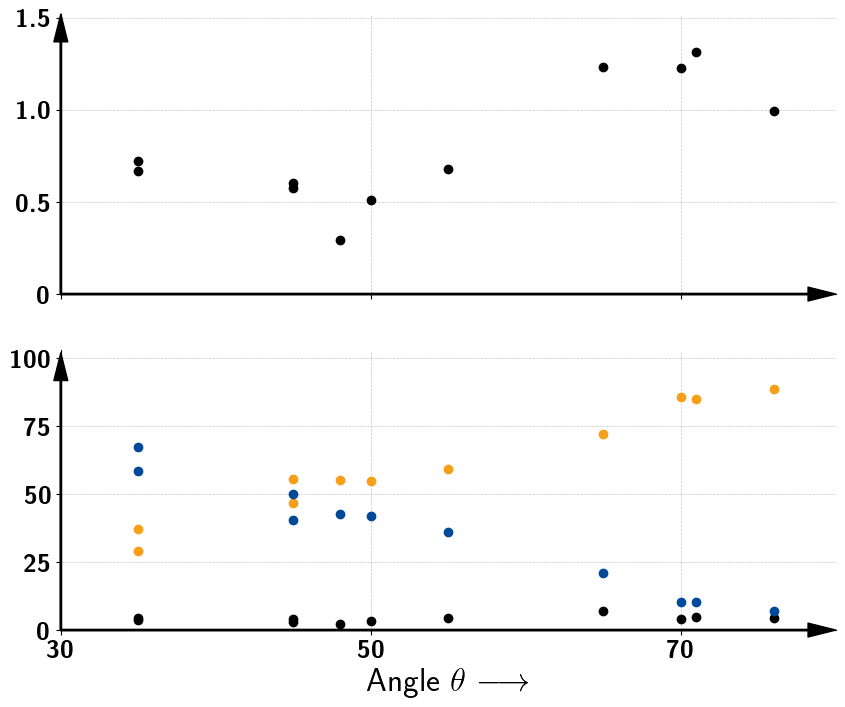

In [4]:
from weac.components import (
    Layer,
    Config,
    ScenarioConfig,
    ModelInput,
    WeakLayer,
    Segment,
)
import matplotlib.pyplot as plt
from weac.core.system_model import SystemModel, Slab
from weac.analysis.analyzer import Analyzer
from weac.analysis.plotter import Plotter

dataFrame = pd.read_excel('2024_mode_III.xlsx',sheet_name='mode_III_general',usecols='C:R',skiprows=4,header =1)
dataFrame.set_index('exp_num')

colors = ['#F79F19', '#004A99', '#000000']
dropExperiments = [0,1,2,3,8,13]#range(7,len(list(dataFrame))+1)#[11,12]#

filtered=dataFrame.drop(dropExperiments)

fig, axs = plt.subplots(2,1,figsize = (10,8))
axs = axs.flatten()

# fig,axs = plt.subplots(3,2,constrained_layout=False, figsize = (8,9))
# axs=axs.flatten()

output=np.zeros((len(list(dataFrame)),7))

for index, data in filtered.iterrows():
    
    layers = [Layer(rho = data['rho_1'], h = data['h_slab']*10/3.),
              Layer(rho = data['rho_2'], h = data['h_slab']*10/3.),
              Layer(rho = data['rho_3'], h = data['h_slab']*10/3.)]
    
    weak_layer = WeakLayer(rho = 125, h = 15, E=0.15,constitutive_model='PlaneStrain')

    segments = [Segment(length = data['a_critical']*10,has_foundation=False,
                        is_loaded=True,m=0),
                Segment(length = data['slablength']*10-data['a_critical']*10,
                        has_foundation=True,is_loaded=False,m=0),
                ]
    if data['sample_num']==15:
        loadCase = 1
    elif data['sample_num']==17:
        loadCase =2
    else: 
        loadCase=0

    Fx,Fy,Fz,Mx,My,Mz = get_additional_weight_load(
                                        H=data['h_slab']*10,
                                         phi=0,
                                         theta = data['omega'],
                                         n = data['weights'], 
                                         l = data['l_weight']*10,
                                         case = loadCase,
                                         frame = (data['weights']!=0),)
    modeIII_scenario = ScenarioConfig(system_type = '-pst',
                                      phi = 0, 
                                      theta = data['omega'], 
                                      surface_load=0,
                                      load_vector_left=np.array([Fx, Fy, Fz, Mx, My, Mz]),
                                      load_vector_right=np.array([0,0,0,0,0,0]),
                                      )
    config = Config(touchdown = False, 
                    backend = 'generalized', 
                    b = 290)

    modelInput = ModelInput(layers=layers, 
                            weak_layer=weak_layer,
                            segments=segments, 
                            scenario_config=modeIII_scenario)

    system = SystemModel(model_input=modelInput,
                         config=config,)
    modeIII_analyzer = Analyzer(system_model=system)

    
    
    
    g = modeIII_analyzer.differential_ERR(unit = 'J/m^2')
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    
   
    output[index-1,:]=np.array([data['omega'],Fy, Mx, g[1]/g[0],g[2]/g[0],g[3]/g[0], g[0]])
    axs[0].plot(data['omega'],g[0],'ok')

    axs[1].plot(data['omega'],g[3]/g[0]*100,'o',c = colors[0], label = 'mode III')
    axs[1].plot(data['omega'],g[2]/g[0]*100,'o',c = colors[2], label = 'mode II')
    axs[1].plot(data['omega'],g[1]/g[0]*100,'o',c = colors[1], label = 'mode I')
    
    # axs[3].plot(g[1]/g[0], g[3]/g[0],'.')

    

    #axs.plot(Fy, g[3]/g[0],'.k')
    # axs[5].plot(Mx, g[3]/g[0],'.')
axs[0].tick_params(labelsize=18, )
axs[1].tick_params(labelsize=18)
plt.rcParams['text.usetex'] = True
#axs.set_xlabel(r'Angle $\theta$ (°)')
# axs.set_ylabel(r'$\mathcal{G}_c$ (J/m$^2$)')
#axs[0].set_ylabel(r' Fracture toughness \\  $\mathcal{G}_c$ (J/m$^2$)',fontsize=24, fontdict={'family':'sans-serif'})
axs[0].set_xlim([30,80])
# axs.set_ylim([0,100])
axs[0].set_xticklabels([])
# axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])
axs[0].set_ylim([0,1.52])
axs[0].set_yticks([0,0.5,1,1.5])
axs[0].set_yticklabels([r'\textbf{0}', r'\textbf{0.5}', r'\textbf{1.0}', r'\textbf{1.5}'])
axs[0].set_xticks([30,50,70])
axs[0].set_xticklabels(['','', ''])
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

axs[1].set_ylim([0,103])
axs[1].set_yticks([0,25,50,75,100])
axs[1].set_yticklabels([r'\textbf{0}', r'\textbf{25}', r'\textbf{50}', r'\textbf{75}', r'\textbf{100}'])
# axs[1].set_xlabel(r'Angle $\theta$')
#axs[1].set_ylabel(r' \centering Mode contribution \\ \centering $\mathcal{G}_{i}$/$\mathcal{G}_c$ (\%)',fontsize=24, fontdict={'family':'sans-serif'} ,)
axs[1].set_xlim([30,80])
axs[1].set_xticks([30,50,70])
axs[1].set_xticklabels([r'\textbf{30}', r'\textbf{50}', r'\textbf{70}'])
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
# plt.text(32,0.68,'mode I')
# plt.text(32,0.25,'mode III')
# plt.text(32,0.1,'mode II')

#xs.set_xlabel(r'Angle $\theta$ $\longrightarrow$',fontsize=14)
# axs.spines['top'].set_visible(False)
# axs.spines['right'].set_visible(False)
# axs.annotate('', xy=(80, 0), xytext=(30, 0),
#             arrowprops=dict( width = 1., headlength = 20., headwidth = 10. , color = 'black'))  # X-axis arrow

axs[1].set_xlabel(r'Angle $\theta$ $\longrightarrow$',fontsize=24, fontdict={'family':'sans-serif'})
# axs.annotate('', xy=(30, 3.5), xytext=(30, 0),
#             arrowprops=dict( width = 1., headlength = 20., headwidth = 10., color = 'black' ))  # Y-axis arrow
# axs[2].set_ylabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')

# axs[3].set_xlabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')
# axs[3].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')
# axs[3].set_xlim(0,1)
# axs[3].set_ylim(0,1)

#axs.set_xlabel(r'$V_y$ (N)')
# axs[4].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')

# axs[5].set_xlabel(r'$M_x$ (Nmm)')
# axs[5].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')

output=output[output[:,0]!=0,:]

standardOutput=np.vstack([output[0,:], output[2,:], output[4:,:]])
specialOutput=np.vstack([output[1,:], output[3,:]])

axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].annotate('', xy=(80, 0), xytext=(30, 0),
            arrowprops=dict( width = 1., headlength = 20., headwidth = 10. , color = 'black'))  # X-axis arrow
axs[0].annotate('', xy=(30, 1.52), xytext=(30, 0),
           arrowprops=dict( width = 1., headlength = 20., headwidth = 10., color = 'black' ))  # Y-axis arrow


axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)
axs[1].annotate('', xy=(80, 0), xytext=(30, 0),
            arrowprops=dict( width = 1., headlength = 20., headwidth =  10.,
                            color ='black'))
axs[1].annotate('', xy=(30, 102), xytext=(30, 0),
           arrowprops=dict( width = 1., headlength = 20., headwidth = 10., color = 'black' ))  # Y-axis arrow
# fig.tight_layout()
# np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/expPlotModeI.dat',np.vstack([standardOutput[:,0], standardOutput[:,3]]).T)
# np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/expPlotModeII.dat',np.vstack([standardOutput[:,0], standardOutput[:,4]]).T)
# np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/expPlotModeIII.dat',np.vstack([standardOutput[:,0], standardOutput[:,5]]).T)
# np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/expPlotERR.dat',np.vstack([standardOutput[:,0], standardOutput[:,6]]).T)

# np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/expPlotModeISpecial.dat',np.vstack([specialOutput[:,0], specialOutput[:,3]]).T)
# np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/expPlotModeIISpecial.dat',np.vstack([specialOutput[:,0], specialOutput[:,4]]).T)
# np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/expPlotModeIIISpecial.dat',np.vstack([specialOutput[:,0], specialOutput[:,5]]).T)
# np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/expPlotERRSpecial.dat',np.vstack([specialOutput[:,0], specialOutput[:,6]]).T)
    # axs[index].plot(xwl,modeIII_pst.sigzz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauxz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauyz(z,unit = 'kPa'))
    #print(modeIII_pst.A11,modeIII_pst.B11,modeIII_pst.D11,modeIII_pst.kA55,modeIII_pst.kB55,modeIII_pst.kD55)
    #

    #print(modeIII_pst.slab[:,2])
    
    #print(modeIII_pst.zp(x=10*(data['a_critical']), phi = 0, theta =38, bed = False))
    #print(g)

    





C:\Users\Florian Rheinschmidt\AppData\Local\Temp\ipykernel_29844\1066152261.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])


0.8032583185682256


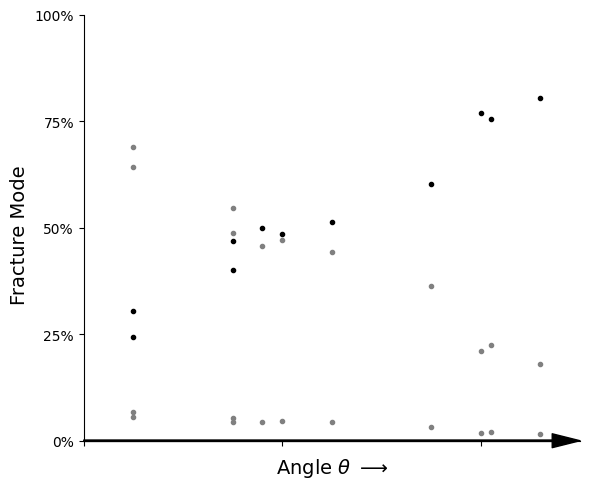

In [13]:
dataFrame = pd.read_excel('2024_mode_III.xlsx',sheet_name='mode_III_general',usecols='C:R',skiprows=4,header =1)
dataFrame.set_index('exp_num')


dropExperiments = [0,1,2,3,8,13]#range(7,len(list(dataFrame))+1)#[11,12]#

filtered=dataFrame.drop(dropExperiments)

fig = plt.figure(figsize = (6,5))
axs = plt.gca()
# fig,axs = plt.subplots(3,2,constrained_layout=False, figsize = (8,9))
# axs=axs.flatten()

output=np.zeros((len(list(dataFrame)),6))

for index, data in filtered.iterrows():
    
    layers = [[data['rho_1'],data['h_slab']*10/3.],
              [data['rho_2'],data['h_slab']*10/3.],
              [data['rho_3'],data['h_slab']*10/3.]]
    
    modeIII_pst = oop.Layered(layers=layers, system = 'pst-', phi = 0, theta = data['omega'])
    if data['sample_num']==15:
        loadCase = 1
    elif data['sample_num']==17:
        loadCase =2
    else: 
        loadCase=0
    
    modeIII_pst.set_foundation_properties(E=0.15, t = 15., update = True)
    modeIII_pst.b = 300.
    segments = modeIII_pst.calc_segments(L = data['slablength']*10, a = data['a_critical']*10, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = data['omega'],
                                        n_rod = data['weights'], 
                                        l_rod = data['l_weight']*10,
                                        frame = (data['weights']!=0),
                                        loadCase=loadCase,
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = data['omega'],**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = data['omega'],unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    
    Fx,Fy,Fz,Mx,My,Mz = modeIII_pst.get_additional_weight_load(
                                         phi=0,
                                         theta = data['omega'],
                                         n = data['weights'], 
                                         l = data['l_weight']*10,
                                         case = loadCase,
                                         frame = (data['weights']!=0),)
    output[index-1,:]=np.array([data['omega'],Fy, Mx, g[1]/g[0],g[2]/g[0],g[3]/g[0]])
    axs.plot(data['omega'],g[3]/g[0]*1e2,'.k')
    axs.plot(data['omega'],g[1]/g[0]*1e2,'.', color = 'gray')
    axs.plot(data['omega'],g[2]/g[0]*1e2,'.', color = 'gray')
    # axs[3].plot(g[1]/g[0], g[3]/g[0],'.')

    

    #axs.plot(Fy, g[3]/g[0],'.k')
    # axs[5].plot(Mx, g[3]/g[0],'.')

#axs.set_xlabel(r'Angle $\theta$ (°)')
# axs.set_ylabel(r'$\mathcal{G}_c$ (J/m$^2$)')
axs.set_ylabel(r'Fracture Mode  ',fontsize=14)
axs.set_xlim([30,80])
axs.set_ylim([0,100])
axs.set_xticklabels([])
axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])

print(max(output[:,-1]))
axs.set_xticks([30,50,70])
axs.set_yticks([0,25,50,75,100])
# axs[1].set_xlabel(r'Angle $\theta$')
#axs.set_ylabel(r'$\mathcal{G}_{\mathrm{III}}$/$\mathcal{G}_c$ (-)')

# plt.text(32,0.68,'mode I')
# plt.text(32,0.25,'mode III')
# plt.text(32,0.1,'mode II')

axs.set_xlabel(r'Angle $\theta$ $\longrightarrow$',fontsize=14)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.annotate('', xy=(80, 0), xytext=(30, 0),
            arrowprops=dict( width = 1., headlength = 20., headwidth = 10. , color = 'black'))  # X-axis arrow
# axs.annotate('', xy=(30, 3.5), xytext=(30, 0),
#             arrowprops=dict( width = 1., headlength = 20., headwidth = 10., color = 'black' ))  # Y-axis arrow
# axs[2].set_ylabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')

# axs[3].set_xlabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')
# axs[3].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')
# axs[3].set_xlim(0,1)
# axs[3].set_ylim(0,1)

#axs.set_xlabel(r'$V_y$ (N)')
# axs[4].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')

# axs[5].set_xlabel(r'$M_x$ (Nmm)')
# axs[5].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')



fig.tight_layout()
np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/expPlotModeI.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,3]]).T)
np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/expPlotModeII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,4]]).T)
np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/expPlotModeIII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,5]]).T)
    # axs[index].plot(xwl,modeIII_pst.sigzz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauxz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauyz(z,unit = 'kPa'))
    #print(modeIII_pst.A11,modeIII_pst.B11,modeIII_pst.D11,modeIII_pst.kA55,modeIII_pst.kB55,modeIII_pst.kD55)
    #

    #print(modeIII_pst.slab[:,2])
    
    #print(modeIII_pst.zp(x=10*(data['a_critical']), phi = 0, theta =38, bed = False))
    #print(g)

    





0.0


C:\Users\Florian Rheinschmidt\AppData\Local\Temp\ipykernel_29844\3521868805.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])


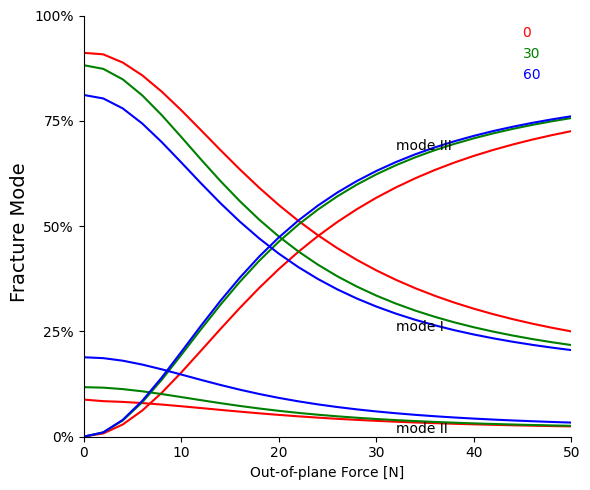

In [7]:
dataFrame = pd.read_excel('2024_mode_III.xlsx',sheet_name='mode_III_general',usecols='C:R',skiprows=4,header =1)
dataFrame.set_index('exp_num')
aLength = 100


V = np.arange(0,200,2)
results = np.zeros((len(V),13))
results[:,0]=np.array(V)
dropExperiments = [0,1,2,3,5,7,8,13]#range(7,len(list(dataFrame))+1)#[11,12]#

filtered=dataFrame.drop(dropExperiments)
meanDensity1 = filtered["rho_1"].mean()
meanDensity2 = filtered["rho_2"].mean()
meanDensity3 = filtered["rho_3"].mean()

meanHeight = filtered["h_slab"].mean()*10.

layers = [[meanDensity1,meanHeight/3],
              [meanDensity2,meanHeight/3],
              [meanDensity3,meanHeight/3]]
fig = plt.figure(figsize = (6,5))
axs = plt.gca()
# fig,axs = plt.subplots(3,2,constrained_layout=False, figsize = (8,9))
# axs=axs.flatten()
modeIII_pst = oop.Layered(layers=layers, system = 'pst-', phi = 0, theta =0)
output=np.zeros((len(V),13))
modeIII_pst.set_foundation_properties(E=0.15, t = 15., update = True)
modeIII_pst.b = 300.
modeIII_pst.calc_fundamental_system()
segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
for index, force in enumerate(V):
    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    
    results[index,1]=g[0]
    results[index,2]=g[1]/g[0]
    results[index,3]=g[2]/g[0]
    results[index,4]=g[3]/g[0]

    #output[index-1,:]=np.array([data['omega'],Fy, Mx, g[1]/g[0],g[2]/g[0],g[3]/g[0]])
    # axs.plot(force,g[3]/g[0]*1e2,'.k')
    # axs.plot(force,g[1]/g[0]*1e2,'.', color = 'gray')
    # axs.plot(force,g[2]/g[0]*1e2,'.', color = 'gray')
    # axs[3].plot(g[1]/g[0], g[3]/g[0],'.')
    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    modeIII_pst.phi=30
    C = modeIII_pst.assemble_and_solve(phi = 30, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=30, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=30, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    results[index,5]=g[0]
    results[index,6]=g[1]/g[0]
    results[index,7]=g[2]/g[0]
    results[index,8]=g[3]/g[0]
    
    modeIII_pst.phi=60
    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 60, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=60, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=60, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    results[index,9]=g[0]
    results[index,10]=g[1]/g[0]
    results[index,11]=g[2]/g[0]
    results[index,12]=g[3]/g[0]
    #output[index-1,:]=np.array([data['omega'],Fy, Mx, g[1]/g[0],g[2]/g[0],g[3]/g[0]])
    # axs.plot(force,g[3]/g[0]*1e2,'.k')
    # axs.plot(force,g[1]/g[0]*1e2,'.', color = 'gray')
    # axs.plot(force,g[2]/g[0]*1e2,'.', color = 'gray')

    #axs.plot(Fy, g[3]/g[0],'.k')
    # axs[5].plot(Mx, g[3]/g[0],'.')
np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/modeIIIexperimentDesignPhi.dat',results)
#axs.set_xlabel(r'Angle $\theta$ (°)')
# axs.set_ylabel(r'$\mathcal{G}_c$ (J/m$^2$)')
axs.set_ylabel(r'Fracture Mode  ',fontsize=14)
axs.set_xlim([0,50])
axs.set_ylim([0,100])
axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])

print(max(output[:,-1]))
axs.set_xticks([0,10,20,30,40,50])
axs.set_yticks([0,25,50,75,100])
axs.set_xlabel(r'Out-of-plane Force [N]')
#axs.set_ylabel(r'$\mathcal{G}_{\mathrm{III}}$/$\mathcal{G}_c$ (-)')

plt.text(32,68,'mode III')
plt.text(32,25,'mode I')
plt.text(32,1,'mode II')

plt.text(45,95,'0',color='r')
plt.text(45,90,'30',color='g')
plt.text(45,85,'60',color='b')

#axs.set_xlabel(r'Angle $\theta$ $\longrightarrow$',fontsize=14)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.annotate('', xy=(80, 0), xytext=(30, 0),
            arrowprops=dict( width = 1., headlength = 20., headwidth = 10. , color = 'black'))  # X-axis arrow
# axs.annotate('', xy=(30, 3.5), xytext=(30, 0),
#             arrowprops=dict( width = 1., headlength = 20., headwidth = 10., color = 'black' ))  # Y-axis arrow
# axs[2].set_ylabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')

# axs[3].set_xlabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')
# axs[3].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')
# axs[3].set_xlim(0,1)
# axs[3].set_ylim(0,1)

#axs.set_xlabel(r'$V_y$ (N)')
# axs[4].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')

# axs[5].set_xlabel(r'$M_x$ (Nmm)')
# axs[5].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')



fig.tight_layout()
#np.savetxt('expPlotModeI.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,3]]).T)
#np.savetxt('expPlotModeII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,4]]).T)
#np.savetxt('expPlotModeIII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,5]]).T)
    # axs[index].plot(xwl,modeIII_pst.sigzz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauxz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauyz(z,unit = 'kPa'))
    #print(modeIII_pst.A11,modeIII_pst.B11,modeIII_pst.D11,modeIII_pst.kA55,modeIII_pst.kB55,modeIII_pst.kD55)
    #

    #print(modeIII_pst.slab[:,2])
    
    #print(modeIII_pst.zp(x=10*(data['a_critical']), phi = 0, theta =38, bed = False))
    #print(g)

    
plt.plot(results[:,0],results[:,2]*1e2,'r')
plt.plot(results[:,0],results[:,3]*1e2,'r')
plt.plot(results[:,0],results[:,4]*1e2,'r')

plt.plot(results[:,0],results[:,6]*1e2,'g')
plt.plot(results[:,0],results[:,7]*1e2,'g')
plt.plot(results[:,0],results[:,8]*1e2,'g')

plt.plot(results[:,0],results[:,10]*1e2,'b')
plt.plot(results[:,0],results[:,11]*1e2,'b')
plt.plot(results[:,0],results[:,12]*1e2,'b')

plt.show()



0.0


C:\Users\Florian Rheinschmidt\AppData\Local\Temp\ipykernel_29844\2728605437.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])


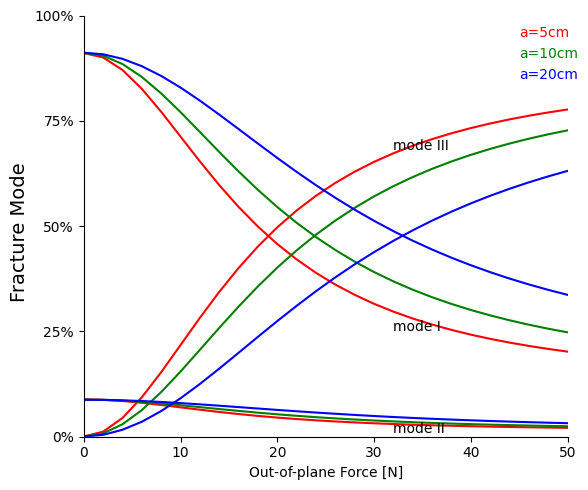

In [15]:
dataFrame = pd.read_excel('2024_mode_III.xlsx',sheet_name='mode_III_general',usecols='C:R',skiprows=4,header =1)
dataFrame.set_index('exp_num')
aLength = 100


V = np.arange(0,200,2)
results = np.zeros((len(V),13))
results[:,0]=np.array(V)
dropExperiments = [0,1,2,3,5,7,8,13]#range(7,len(list(dataFrame))+1)#[11,12]#

filtered=dataFrame.drop(dropExperiments)
meanDensity1 = filtered["rho_1"].mean()
meanDensity2 = filtered["rho_2"].mean()
meanDensity3 = filtered["rho_3"].mean()

meanHeight = filtered["h_slab"].mean()*10.

layers = [[meanDensity1,meanHeight/3],
              [meanDensity2,meanHeight/3],
              [meanDensity3,meanHeight/3]]
fig = plt.figure(figsize = (6,5))
axs = plt.gca()
# fig,axs = plt.subplots(3,2,constrained_layout=False, figsize = (8,9))
# axs=axs.flatten()
modeIII_pst = oop.Layered(layers=layers, system = 'pst-', phi = 0, theta =0)
output=np.zeros((len(V),13))
modeIII_pst.set_foundation_properties(E=0.15, t = 15., update = True)
modeIII_pst.b = 300.
modeIII_pst.calc_fundamental_system()
segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
for index, force in enumerate(V):
    segments = modeIII_pst.calc_segments(L = 1000, a =0.5*aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    
    results[index,1]=g[0]
    results[index,2]=g[1]/g[0]
    results[index,3]=g[2]/g[0]
    results[index,4]=g[3]/g[0]

    #output[index-1,:]=np.array([data['omega'],Fy, Mx, g[1]/g[0],g[2]/g[0],g[3]/g[0]])
    # axs.plot(force,g[3]/g[0]*1e2,'.k')
    # axs.plot(force,g[1]/g[0]*1e2,'.', color = 'gray')
    # axs.plot(force,g[2]/g[0]*1e2,'.', color = 'gray')
    # axs[3].plot(g[1]/g[0], g[3]/g[0],'.')
    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    results[index,5]=g[0]
    results[index,6]=g[1]/g[0]
    results[index,7]=g[2]/g[0]
    results[index,8]=g[3]/g[0]
    

    segments = modeIII_pst.calc_segments(L = 1000, a =aLength*2, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    results[index,9]=g[0]
    results[index,10]=g[1]/g[0]
    results[index,11]=g[2]/g[0]
    results[index,12]=g[3]/g[0]
    #output[index-1,:]=np.array([data['omega'],Fy, Mx, g[1]/g[0],g[2]/g[0],g[3]/g[0]])
    # axs.plot(force,g[3]/g[0]*1e2,'.k')
    # axs.plot(force,g[1]/g[0]*1e2,'.', color = 'gray')
    # axs.plot(force,g[2]/g[0]*1e2,'.', color = 'gray')

    #axs.plot(Fy, g[3]/g[0],'.k')
    # axs[5].plot(Mx, g[3]/g[0],'.')
np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/modeIIIexperimentDesignA.dat',results)
#axs.set_xlabel(r'Angle $\theta$ (°)')
# axs.set_ylabel(r'$\mathcal{G}_c$ (J/m$^2$)')
axs.set_ylabel(r'Fracture Mode  ',fontsize=14)
axs.set_xlim([0,50])
axs.set_ylim([0,100])
axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])

print(max(output[:,-1]))
axs.set_xticks([0,10,20,30,40,50])
axs.set_yticks([0,25,50,75,100])
axs.set_xlabel(r'Out-of-plane Force [N]')
#axs.set_ylabel(r'$\mathcal{G}_{\mathrm{III}}$/$\mathcal{G}_c$ (-)')

plt.text(32,68,'mode III')
plt.text(32,25,'mode I')
plt.text(32,1,'mode II')

plt.text(45,95,'a=5cm',color='r')
plt.text(45,90,'a=10cm',color='g')
plt.text(45,85,'a=20cm',color='b')

#axs.set_xlabel(r'Angle $\theta$ $\longrightarrow$',fontsize=14)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.annotate('', xy=(80, 0), xytext=(30, 0),
            arrowprops=dict( width = 1., headlength = 20., headwidth = 10. , color = 'black'))  # X-axis arrow
# axs.annotate('', xy=(30, 3.5), xytext=(30, 0),
#             arrowprops=dict( width = 1., headlength = 20., headwidth = 10., color = 'black' ))  # Y-axis arrow
# axs[2].set_ylabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')

# axs[3].set_xlabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')
# axs[3].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')
# axs[3].set_xlim(0,1)
# axs[3].set_ylim(0,1)

#axs.set_xlabel(r'$V_y$ (N)')
# axs[4].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')

# axs[5].set_xlabel(r'$M_x$ (Nmm)')
# axs[5].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')



fig.tight_layout()
#np.savetxt('expPlotModeI.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,3]]).T)
#np.savetxt('expPlotModeII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,4]]).T)
#np.savetxt('expPlotModeIII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,5]]).T)
    # axs[index].plot(xwl,modeIII_pst.sigzz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauxz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauyz(z,unit = 'kPa'))
    #print(modeIII_pst.A11,modeIII_pst.B11,modeIII_pst.D11,modeIII_pst.kA55,modeIII_pst.kB55,modeIII_pst.kD55)
    #

    #print(modeIII_pst.slab[:,2])
    
    #print(modeIII_pst.zp(x=10*(data['a_critical']), phi = 0, theta =38, bed = False))
    #print(g)

    
plt.plot(results[:,0],results[:,2]*1e2,'r')
plt.plot(results[:,0],results[:,3]*1e2,'r')
plt.plot(results[:,0],results[:,4]*1e2,'r')

plt.plot(results[:,0],results[:,6]*1e2,'g')
plt.plot(results[:,0],results[:,7]*1e2,'g')
plt.plot(results[:,0],results[:,8]*1e2,'g')

plt.plot(results[:,0],results[:,10]*1e2,'b')
plt.plot(results[:,0],results[:,11]*1e2,'b')
plt.plot(results[:,0],results[:,12]*1e2,'b')

plt.show()



Positioning

0.0


C:\Users\Florian Rheinschmidt\AppData\Local\Temp\ipykernel_29844\1049752146.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])


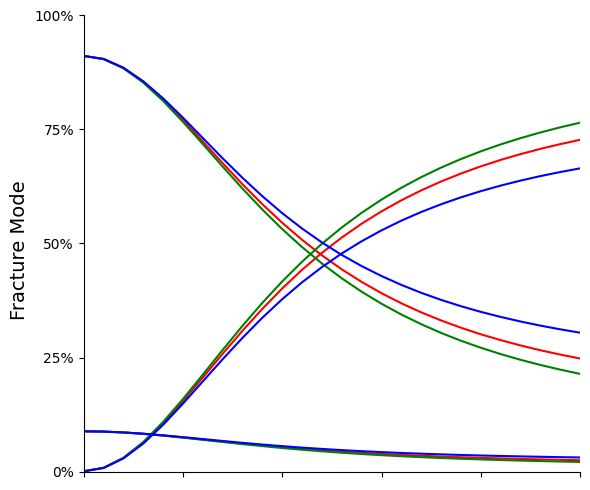

In [10]:
dataFrame = pd.read_excel('2024_mode_III.xlsx',sheet_name='mode_III_general',usecols='C:R',skiprows=4,header =1)
dataFrame.set_index('exp_num')
aLength = 100


V = np.arange(0,200,2)
results = np.zeros((len(V),13))
results[:,0]=np.array(V)
dropExperiments = [0,1,2,3,5,7,8,13]#range(7,len(list(dataFrame))+1)#[11,12]#

filtered=dataFrame.drop(dropExperiments)
meanDensity1 = filtered["rho_1"].mean()
meanDensity2 = filtered["rho_2"].mean()
meanDensity3 = filtered["rho_3"].mean()

meanHeight = filtered["h_slab"].mean()*10.

layers = [[meanDensity1,meanHeight/3],
              [meanDensity2,meanHeight/3],
              [meanDensity3,meanHeight/3]]
fig = plt.figure(figsize = (6,5))
axs = plt.gca()
# fig,axs = plt.subplots(3,2,constrained_layout=False, figsize = (8,9))
# axs=axs.flatten()
modeIII_pst = oop.Layered(layers=layers, system = 'pst-', phi = 0, theta =0)
output=np.zeros((len(V),10))
modeIII_pst.set_foundation_properties(E=0.15, t = 15., update = True)
modeIII_pst.b = 300.
modeIII_pst.calc_fundamental_system()
segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
for index, force in enumerate(V):
    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    
    results[index,1]=g[0]
    results[index,2]=g[1]/g[0]
    results[index,3]=g[2]/g[0]
    results[index,4]=g[3]/g[0]

    #output[index-1,:]=np.array([data['omega'],Fy, Mx, g[1]/g[0],g[2]/g[0],g[3]/g[0]])
    # axs.plot(force,g[3]/g[0]*1e2,'.k')
    # axs.plot(force,g[1]/g[0]*1e2,'.', color = 'gray')
    # axs.plot(force,g[2]/g[0]*1e2,'.', color = 'gray')
    # axs[3].plot(g[1]/g[0], g[3]/g[0],'.')
    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,meanHeight/2.],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    results[index,5]=g[0]
    results[index,6]=g[1]/g[0]
    results[index,7]=g[2]/g[0]
    results[index,8]=g[3]/g[0]
    

    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,-meanHeight/2],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    results[index,9]=g[0]
    results[index,10]=g[1]/g[0]
    results[index,11]=g[2]/g[0]
    results[index,12]=g[3]/g[0]
    #output[index-1,:]=np.array([data['omega'],Fy, Mx, g[1]/g[0],g[2]/g[0],g[3]/g[0]])
    # axs.plot(force,g[3]/g[0]*1e2,'.k')
    # axs.plot(force,g[1]/g[0]*1e2,'.', color = 'gray')
    # axs.plot(force,g[2]/g[0]*1e2,'.', color = 'gray')

    #axs.plot(Fy, g[3]/g[0],'.k')
    # axs[5].plot(Mx, g[3]/g[0],'.')
np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/modeIIIexperimentDesignPos.dat',results)
#axs.set_xlabel(r'Angle $\theta$ (°)')
# axs.set_ylabel(r'$\mathcal{G}_c$ (J/m$^2$)')
axs.set_ylabel(r'Fracture Mode  ',fontsize=14)
axs.set_xlim([0,50])
axs.set_ylim([0,100])
axs.set_xticklabels([])
axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])

print(max(output[:,-1]))
axs.set_xticks([0,10,20,30,40,50])
axs.set_yticks([0,25,50,75,100])
# axs[1].set_xlabel(r'Angle $\theta$')
#axs.set_ylabel(r'$\mathcal{G}_{\mathrm{III}}$/$\mathcal{G}_c$ (-)')

# plt.text(32,0.68,'mode I')
# plt.text(32,0.25,'mode III')
# plt.text(32,0.1,'mode II')

#axs.set_xlabel(r'Angle $\theta$ $\longrightarrow$',fontsize=14)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.annotate('', xy=(80, 0), xytext=(30, 0),
            arrowprops=dict( width = 1., headlength = 20., headwidth = 10. , color = 'black'))  # X-axis arrow
# axs.annotate('', xy=(30, 3.5), xytext=(30, 0),
#             arrowprops=dict( width = 1., headlength = 20., headwidth = 10., color = 'black' ))  # Y-axis arrow
# axs[2].set_ylabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')

# axs[3].set_xlabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')
# axs[3].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')
# axs[3].set_xlim(0,1)
# axs[3].set_ylim(0,1)

#axs.set_xlabel(r'$V_y$ (N)')
# axs[4].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')

# axs[5].set_xlabel(r'$M_x$ (Nmm)')
# axs[5].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')



fig.tight_layout()
plt.plot(results[:,0],results[:,2]*1e2,'r')
plt.plot(results[:,0],results[:,3]*1e2,'r')
plt.plot(results[:,0],results[:,4]*1e2,'r')

plt.plot(results[:,0],results[:,6]*1e2,'g')
plt.plot(results[:,0],results[:,7]*1e2,'g')
plt.plot(results[:,0],results[:,8]*1e2,'g')

plt.plot(results[:,0],results[:,10]*1e2,'b')
plt.plot(results[:,0],results[:,11]*1e2,'b')
plt.plot(results[:,0],results[:,12]*1e2,'b')
#np.savetxt('expPlotModeI.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,3]]).T)
#np.savetxt('expPlotModeII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,4]]).T)
#np.savetxt('expPlotModeIII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,5]]).T)
    # axs[index].plot(xwl,modeIII_pst.sigzz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauxz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauyz(z,unit = 'kPa'))
    #print(modeIII_pst.A11,modeIII_pst.B11,modeIII_pst.D11,modeIII_pst.kA55,modeIII_pst.kB55,modeIII_pst.kD55)
    #

    #print(modeIII_pst.slab[:,2])
    
    #print(modeIII_pst.zp(x=10*(data['a_critical']), phi = 0, theta =38, bed = False))
    #print(g)

    





Height

0.0


C:\Users\Florian Rheinschmidt\AppData\Local\Temp\ipykernel_29844\329781580.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])


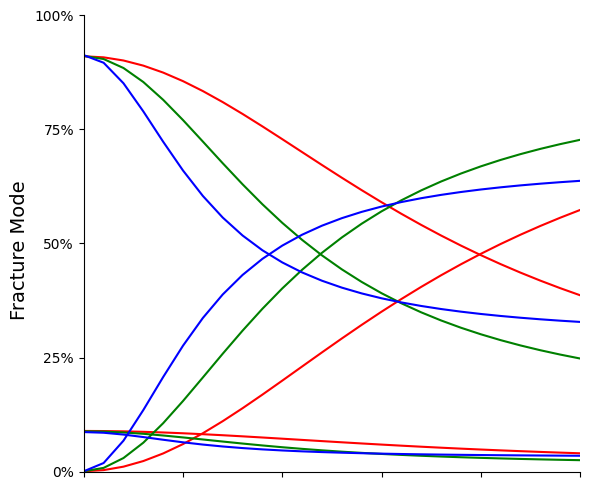

In [11]:
dataFrame = pd.read_excel('2024_mode_III.xlsx',sheet_name='mode_III_general',usecols='C:R',skiprows=4,header =1)
dataFrame.set_index('exp_num')
aLength = 100


V = np.arange(0,200,2)
results = np.zeros((len(V),13))
results[:,0]=np.array(V)
dropExperiments = [0,1,2,3,5,7,8,13]#range(7,len(list(dataFrame))+1)#[11,12]#

filtered=dataFrame.drop(dropExperiments)
meanDensity1 = filtered["rho_1"].mean()
meanDensity2 = filtered["rho_2"].mean()
meanDensity3 = filtered["rho_3"].mean()

meanHeight = filtered["h_slab"].mean()*10.

layers = [[meanDensity1,meanHeight/3],
              [meanDensity2,meanHeight/3],
              [meanDensity3,meanHeight/3]]
fig = plt.figure(figsize = (6,5))
axs = plt.gca()
# fig,axs = plt.subplots(3,2,constrained_layout=False, figsize = (8,9))
# axs=axs.flatten()
modeIII_pst = oop.Layered(layers=layers, system = 'pst-', phi = 0, theta =0)
output=np.zeros((len(V),10))
modeIII_pst.set_foundation_properties(E=0.15, t = 15., update = True)
modeIII_pst.b = 300.
modeIII_pst.calc_fundamental_system()
segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
for index, force in enumerate(V):
    meanHeight = filtered["h_slab"].mean()*10.*2.

    layers = [[meanDensity1,meanHeight/3],
                [meanDensity2,meanHeight/3],
                [meanDensity3,meanHeight/3]]
    modeIII_pst = oop.Layered(layers=layers, system = 'pst-', phi = 0, theta =0)
    modeIII_pst.set_foundation_properties(E=0.15, t = 15., update = True)
    modeIII_pst.b = 300.
    modeIII_pst.calc_fundamental_system()
    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    
    results[index,1]=g[0]
    results[index,2]=g[1]/g[0]
    results[index,3]=g[2]/g[0]
    results[index,4]=g[3]/g[0]

    #output[index-1,:]=np.array([data['omega'],Fy, Mx, g[1]/g[0],g[2]/g[0],g[3]/g[0]])
    # axs.plot(force,g[3]/g[0]*1e2,'.k')
    # axs.plot(force,g[1]/g[0]*1e2,'.', color = 'gray')
    # axs.plot(force,g[2]/g[0]*1e2,'.', color = 'gray')
    # axs[3].plot(g[1]/g[0], g[3]/g[0],'.')
    meanHeight = filtered["h_slab"].mean()*10.

    layers = [[meanDensity1,meanHeight/3],
                [meanDensity2,meanHeight/3],
                [meanDensity3,meanHeight/3]]
    modeIII_pst = oop.Layered(layers=layers, system = 'pst-', phi = 0, theta =0)
    modeIII_pst.set_foundation_properties(E=0.15, t = 15., update = True)
    modeIII_pst.b = 300.
    modeIII_pst.calc_fundamental_system()
    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    results[index,5]=g[0]
    results[index,6]=g[1]/g[0]
    results[index,7]=g[2]/g[0]
    results[index,8]=g[3]/g[0]
    

    meanHeight = filtered["h_slab"].mean()*10./2.

    layers = [[meanDensity1,meanHeight/3],
                [meanDensity2,meanHeight/3],
                [meanDensity3,meanHeight/3]]
    modeIII_pst = oop.Layered(layers=layers, system = 'pst-', phi = 0, theta =0)
    modeIII_pst.set_foundation_properties(E=0.15, t = 15., update = True)
    modeIII_pst.b = 300.
    modeIII_pst.calc_fundamental_system()
    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    results[index,9]=g[0]
    results[index,10]=g[1]/g[0]
    results[index,11]=g[2]/g[0]
    results[index,12]=g[3]/g[0]
    #output[index-1,:]=np.array([data['omega'],Fy, Mx, g[1]/g[0],g[2]/g[0],g[3]/g[0]])
    # axs.plot(force,g[3]/g[0]*1e2,'.k')
    # axs.plot(force,g[1]/g[0]*1e2,'.', color = 'gray')
    # axs.plot(force,g[2]/g[0]*1e2,'.', color = 'gray')

    #axs.plot(Fy, g[3]/g[0],'.k')
    # axs[5].plot(Mx, g[3]/g[0],'.')
np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/modeIIIexperimentDesignHeight.dat',results)
#axs.set_xlabel(r'Angle $\theta$ (°)')
# axs.set_ylabel(r'$\mathcal{G}_c$ (J/m$^2$)')
axs.set_ylabel(r'Fracture Mode  ',fontsize=14)
axs.set_xlim([0,50])
axs.set_ylim([0,100])
axs.set_xticklabels([])
axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])

print(max(output[:,-1]))
axs.set_xticks([0,10,20,30,40,50])
axs.set_yticks([0,25,50,75,100])
# axs[1].set_xlabel(r'Angle $\theta$')
#axs.set_ylabel(r'$\mathcal{G}_{\mathrm{III}}$/$\mathcal{G}_c$ (-)')

# plt.text(32,0.68,'mode I')
# plt.text(32,0.25,'mode III')
# plt.text(32,0.1,'mode II')

#axs.set_xlabel(r'Angle $\theta$ $\longrightarrow$',fontsize=14)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.annotate('', xy=(80, 0), xytext=(30, 0),
            arrowprops=dict( width = 1., headlength = 20., headwidth = 10. , color = 'black'))  # X-axis arrow
# axs.annotate('', xy=(30, 3.5), xytext=(30, 0),
#             arrowprops=dict( width = 1., headlength = 20., headwidth = 10., color = 'black' ))  # Y-axis arrow
# axs[2].set_ylabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')

# axs[3].set_xlabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')
# axs[3].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')
# axs[3].set_xlim(0,1)
# axs[3].set_ylim(0,1)

#axs.set_xlabel(r'$V_y$ (N)')
# axs[4].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')

# axs[5].set_xlabel(r'$M_x$ (Nmm)')
# axs[5].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')



fig.tight_layout()
#np.savetxt('expPlotModeI.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,3]]).T)
#np.savetxt('expPlotModeII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,4]]).T)
#np.savetxt('expPlotModeIII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,5]]).T)
    # axs[index].plot(xwl,modeIII_pst.sigzz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauxz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauyz(z,unit = 'kPa'))
    #print(modeIII_pst.A11,modeIII_pst.B11,modeIII_pst.D11,modeIII_pst.kA55,modeIII_pst.kB55,modeIII_pst.kD55)
    #

    #print(modeIII_pst.slab[:,2])
    
    #print(modeIII_pst.zp(x=10*(data['a_critical']), phi = 0, theta =38, bed = False))
    #print(g)

    

plt.plot(results[:,0],results[:,2]*1e2,'r')
plt.plot(results[:,0],results[:,3]*1e2,'r')
plt.plot(results[:,0],results[:,4]*1e2,'r')

plt.plot(results[:,0],results[:,6]*1e2,'g')
plt.plot(results[:,0],results[:,7]*1e2,'g')
plt.plot(results[:,0],results[:,8]*1e2,'g')

plt.plot(results[:,0],results[:,10]*1e2,'b')
plt.plot(results[:,0],results[:,11]*1e2,'b')
plt.plot(results[:,0],results[:,12]*1e2,'b')



Width

276.94444444444446 308.8333333333333 317.8888888888889 124.44444444444444
2.1533430278411867
0.0


C:\Users\Florian Rheinschmidt\AppData\Local\Temp\ipykernel_29844\98592233.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])


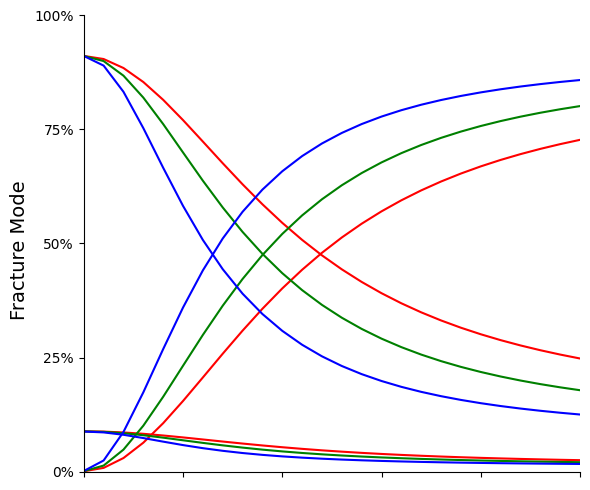

In [12]:
dataFrame = pd.read_excel('2024_mode_III.xlsx',sheet_name='mode_III_general',usecols='C:R',skiprows=4,header =1)
dataFrame.set_index('exp_num')
aLength = 100


V = np.arange(0,200,2)
results = np.zeros((len(V),13))
results[:,0]=np.array(V)
dropExperiments = [0,1,2,3,5,7,8,13]#range(7,len(list(dataFrame))+1)#[11,12]#

filtered=dataFrame.drop(dropExperiments)
meanDensity1 = filtered["rho_1"].mean()
meanDensity2 = filtered["rho_2"].mean()
meanDensity3 = filtered["rho_3"].mean()



meanHeight = filtered["h_slab"].mean()*10.
print(meanDensity1, meanDensity2, meanDensity3, meanHeight)


layers = [[meanDensity1,meanHeight/3],
              [meanDensity2,meanHeight/3],
              [meanDensity3,meanHeight/3]]
fig = plt.figure(figsize = (6,5))
axs = plt.gca()
# fig,axs = plt.subplots(3,2,constrained_layout=False, figsize = (8,9))
# axs=axs.flatten()
modeIII_pst = oop.Layered(layers=layers, system = 'pst-', phi = 0, theta =0)
output=np.zeros((len(V),10))
modeIII_pst.set_foundation_properties(E=0.15, t = 15., update = True)
modeIII_pst.b = 300.
segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
for index, force in enumerate(V):
    modeIII_pst.b = 300.
    modeIII_pst.calc_fundamental_system()
    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    
    results[index,1]=g[0]
    results[index,2]=g[1]/g[0]
    results[index,3]=g[2]/g[0]
    results[index,4]=g[3]/g[0]

    #output[index-1,:]=np.array([data['omega'],Fy, Mx, g[1]/g[0],g[2]/g[0],g[3]/g[0]])
    # axs.plot(force,g[3]/g[0]*1e2,'.k')
    # axs.plot(force,g[1]/g[0]*1e2,'.', color = 'gray')
    # axs.plot(force,g[2]/g[0]*1e2,'.', color = 'gray')
    # axs[3].plot(g[1]/g[0], g[3]/g[0],'.')
    modeIII_pst.b = 250.
    modeIII_pst.calc_fundamental_system()
    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    results[index,5]=g[0]
    results[index,6]=g[1]/g[0]
    results[index,7]=g[2]/g[0]
    results[index,8]=g[3]/g[0]
    
    modeIII_pst.b = 200.
    modeIII_pst.calc_fundamental_system()
    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    results[index,9]=g[0]
    results[index,10]=g[1]/g[0]
    results[index,11]=g[2]/g[0]
    results[index,12]=g[3]/g[0]
    
    # axs.plot(force,g[3]/g[0]*1e2,'.k')
    # axs.plot(force,g[1]/g[0]*1e2,'.', color = 'gray')
    # axs.plot(force,g[2]/g[0]*1e2,'.', color = 'gray')

    #axs.plot(Fy, g[3]/g[0],'.k')
    # axs[5].plot(Mx, g[3]/g[0],'.')
np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/modeIIIexperimentDesignThickness.dat',results)
print(max(results[:,1]))
#axs.set_xlabel(r'Angle $\theta$ (°)')
# axs.set_ylabel(r'$\mathcal{G}_c$ (J/m$^2$)')
axs.set_ylabel(r'Fracture Mode  ',fontsize=14)
axs.set_xlim([0,50])
axs.set_ylim([0,100])
axs.set_xticklabels([])
axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])

print(max(output[:,-1]))
axs.set_xticks([0,10,20,30,40,50])
axs.set_yticks([0,25,50,75,100])
# axs[1].set_xlabel(r'Angle $\theta$')
#axs.set_ylabel(r'$\mathcal{G}_{\mathrm{III}}$/$\mathcal{G}_c$ (-)')

# plt.text(32,0.68,'mode I')
# plt.text(32,0.25,'mode III')
# plt.text(32,0.1,'mode II')

#axs.set_xlabel(r'Angle $\theta$ $\longrightarrow$',fontsize=14)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.annotate('', xy=(80, 0), xytext=(30, 0),
            arrowprops=dict( width = 1., headlength = 20., headwidth = 10. , color = 'black'))  # X-axis arrow
# axs.annotate('', xy=(30, 3.5), xytext=(30, 0),
#             arrowprops=dict( width = 1., headlength = 20., headwidth = 10., color = 'black' ))  # Y-axis arrow
# axs[2].set_ylabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')

# axs[3].set_xlabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')
# axs[3].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')
# axs[3].set_xlim(0,1)
# axs[3].set_ylim(0,1)

#axs.set_xlabel(r'$V_y$ (N)')
# axs[4].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')

# axs[5].set_xlabel(r'$M_x$ (Nmm)')
# axs[5].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')



fig.tight_layout()
#np.savetxt('expPlotModeI.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,3]]).T)
#np.savetxt('expPlotModeII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,4]]).T)
#np.savetxt('expPlotModeIII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,5]]).T)
    # axs[index].plot(xwl,modeIII_pst.sigzz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauxz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauyz(z,unit = 'kPa'))
    #print(modeIII_pst.A11,modeIII_pst.B11,modeIII_pst.D11,modeIII_pst.kA55,modeIII_pst.kB55,modeIII_pst.kD55)
    #

    #print(modeIII_pst.slab[:,2])
    
    #print(modeIII_pst.zp(x=10*(data['a_critical']), phi = 0, theta =38, bed = False))
    #print(g)

    

plt.plot(results[:,0],results[:,2]*1e2,'r')
plt.plot(results[:,0],results[:,3]*1e2,'r')
plt.plot(results[:,0],results[:,4]*1e2,'r')

plt.plot(results[:,0],results[:,6]*1e2,'g')
plt.plot(results[:,0],results[:,7]*1e2,'g')
plt.plot(results[:,0],results[:,8]*1e2,'g')

plt.plot(results[:,0],results[:,10]*1e2,'b')
plt.plot(results[:,0],results[:,11]*1e2,'b')
plt.plot(results[:,0],results[:,12]*1e2,'b')



276.94444444444446 308.8333333333333 317.8888888888889 124.44444444444444
0.0


C:\Users\Florian Rheinschmidt\AppData\Local\Temp\ipykernel_29844\1455777074.py:123: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])


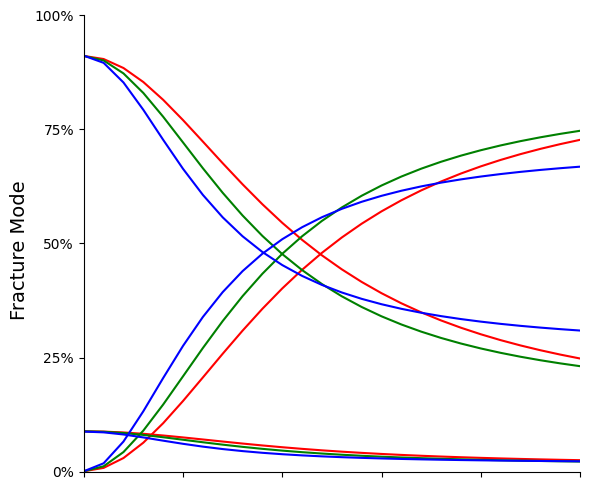

In [16]:
dataFrame = pd.read_excel('2024_mode_III.xlsx',sheet_name='mode_III_general',usecols='C:R',skiprows=4,header =1)
dataFrame.set_index('exp_num')
aLength = 100


V = np.arange(0,200,2)
results = np.zeros((len(V),13))
results[:,0]=np.array(V)
dropExperiments = [0,1,2,3,5,7,8,13]#range(7,len(list(dataFrame))+1)#[11,12]#

filtered=dataFrame.drop(dropExperiments)
meanDensity1 = filtered["rho_1"].mean()
meanDensity2 = filtered["rho_2"].mean()
meanDensity3 = filtered["rho_3"].mean()



meanHeight = filtered["h_slab"].mean()*10.
print(meanDensity1, meanDensity2, meanDensity3, meanHeight)


layers = [[meanDensity1,meanHeight/3],
              [meanDensity2,meanHeight/3],
              [meanDensity3,meanHeight/3]]
fig = plt.figure(figsize = (6,5))
axs = plt.gca()
# fig,axs = plt.subplots(3,2,constrained_layout=False, figsize = (8,9))
# axs=axs.flatten()
modeIII_pst = oop.Layered(layers=layers, system = 'pst-', phi = 0, theta =0)
output=np.zeros((len(V),10))
modeIII_pst.set_foundation_properties(E=0.15, t = 15., update = True)
modeIII_pst.b = 300.
modeIII_pst.calc_fundamental_system()
segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
for index, force in enumerate(V):
    segments = modeIII_pst.calc_segments(L = 1000, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    
    results[index,1]=g[0]
    results[index,2]=g[1]/g[0]
    results[index,3]=g[2]/g[0]
    results[index,4]=g[3]/g[0]

    #output[index-1,:]=np.array([data['omega'],Fy, Mx, g[1]/g[0],g[2]/g[0],g[3]/g[0]])
    # axs.plot(force,g[3]/g[0]*1e2,'.k')
    # axs.plot(force,g[1]/g[0]*1e2,'.', color = 'gray')
    # axs.plot(force,g[2]/g[0]*1e2,'.', color = 'gray')
    # axs[3].plot(g[1]/g[0], g[3]/g[0],'.')
    segments = modeIII_pst.calc_segments(L = 750, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    results[index,5]=g[0]
    results[index,6]=g[1]/g[0]
    results[index,7]=g[2]/g[0]
    results[index,8]=g[3]/g[0]
    

    segments = modeIII_pst.calc_segments(L = 500, a =aLength, m = 0)['crack']
    C = modeIII_pst.assemble_and_solve(phi = 0, 
                                        theta = 0,
                                        frame = False,
                                        verticalLoad=True,
                                        V=[force,0],
                                        **segments)
    xwl, z, xsl = modeIII_pst.rasterize_solution(C,phi=0, theta = 0,**segments)
    g = modeIII_pst.gdif(C, phi=0, theta = 0,unit ='J/m^2', **segments)
    #print(modeIII_pst.slab)
    #axs.plot(data['omega'], g[0],'xk')
    #axs.plot(data['omega'], data['a_critical'],'xk')
    #axs.text(data['omega'],g[0], 'x')
    results[index,9]=g[0]
    results[index,10]=g[1]/g[0]
    results[index,11]=g[2]/g[0]
    results[index,12]=g[3]/g[0]
    #output[index-1,:]=np.array([data['omega'],Fy, Mx, g[1]/g[0],g[2]/g[0],g[3]/g[0]])
    # axs.plot(force,g[3]/g[0]*1e2,'.k')
    # axs.plot(force,g[1]/g[0]*1e2,'.', color = 'gray')
    # axs.plot(force,g[2]/g[0]*1e2,'.', color = 'gray')

    #axs.plot(Fy, g[3]/g[0],'.k')
    # axs[5].plot(Mx, g[3]/g[0],'.')

    
plt.plot(results[:,0],results[:,2]*1e2,'r')
plt.plot(results[:,0],results[:,3]*1e2,'r')
plt.plot(results[:,0],results[:,4]*1e2,'r')

plt.plot(results[:,0],results[:,6]*1e2,'g')
plt.plot(results[:,0],results[:,7]*1e2,'g')
plt.plot(results[:,0],results[:,8]*1e2,'g')

plt.plot(results[:,0],results[:,10]*1e2,'b')
plt.plot(results[:,0],results[:,11]*1e2,'b')
plt.plot(results[:,0],results[:,12]*1e2,'b')
np.savetxt(r'C:/Cloud/01_neueAnsaetze/media/tikz/chapter-6/data/modeIIIexperimentDesignLength.dat',results)
#axs.set_xlabel(r'Angle $\theta$ (°)')
# axs.set_ylabel(r'$\mathcal{G}_c$ (J/m$^2$)')
axs.set_ylabel(r'Fracture Mode  ',fontsize=14)
axs.set_xlim([0,50])
axs.set_ylim([0,100])
axs.set_xticklabels([])
axs.set_yticklabels(['0%', '25%','50%', '75%', '100%'])

print(max(output[:,-1]))
axs.set_xticks([0,10,20,30,40,50])
axs.set_yticks([0,25,50,75,100])
# axs[1].set_xlabel(r'Angle $\theta$')
#axs.set_ylabel(r'$\mathcal{G}_{\mathrm{III}}$/$\mathcal{G}_c$ (-)')

# plt.text(32,0.68,'mode I')
# plt.text(32,0.25,'mode III')
# plt.text(32,0.1,'mode II')

#axs.set_xlabel(r'Angle $\theta$ $\longrightarrow$',fontsize=14)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.annotate('', xy=(80, 0), xytext=(30, 0),
            arrowprops=dict( width = 1., headlength = 20., headwidth = 10. , color = 'black'))  # X-axis arrow
# axs.annotate('', xy=(30, 3.5), xytext=(30, 0),
#             arrowprops=dict( width = 1., headlength = 20., headwidth = 10., color = 'black' ))  # Y-axis arrow
# axs[2].set_ylabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')

# axs[3].set_xlabel(r'$\mathcal{G}_{Ic}$/$\mathcal{G}_c$ (-)')
# axs[3].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')
# axs[3].set_xlim(0,1)
# axs[3].set_ylim(0,1)

#axs.set_xlabel(r'$V_y$ (N)')
# axs[4].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')

# axs[5].set_xlabel(r'$M_x$ (Nmm)')
# axs[5].set_ylabel(r'$\mathcal{G}_{IIIc}$/$\mathcal{G}_c$ (-)')



fig.tight_layout()
#np.savetxt('expPlotModeI.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,3]]).T)
#np.savetxt('expPlotModeII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,4]]).T)
#np.savetxt('expPlotModeIII.dat',np.vstack([output[output[:,0]!=0,0], output[output[:,0]!=0,5]]).T)
    # axs[index].plot(xwl,modeIII_pst.sigzz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauxz(z,unit = 'kPa'))
    # axs[index].plot(xwl,modeIII_pst.tauyz(z,unit = 'kPa'))
    #print(modeIII_pst.A11,modeIII_pst.B11,modeIII_pst.D11,modeIII_pst.kA55,modeIII_pst.kB55,modeIII_pst.kD55)
    #

    #print(modeIII_pst.slab[:,2])
    
    #print(modeIII_pst.zp(x=10*(data['a_critical']), phi = 0, theta =38, bed = False))
    #print(g)

    





In [12]:
print(dataFrame.loc[3])

exp_num                                      4
sample_num                                   6
date                       2024-01-31 00:00:00
omega                                       45
h_slab                                    12.5
l_weight                                 -17.5
weights                                      4
a_critical                                72.0
propagation                                 FP
slablength                                 100
rho_1                                    325.5
rho_2                                    330.5
rho_3                                    384.5
T_slab                                    -1.8
T_wl                                      -1.6
note           a lot of ice in the second half
Name: 3, dtype: object
